Импорт библиотек и устройство

In [57]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision
import torch
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import models
from torchvision.transforms import functional
from torchvision.transforms import InterpolationMode
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset, TensorDataset, random_split
import json
import os
import math
import time
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

device: cpu
torch: 2.10.0+cpu
torchvision: 0.25.0+cpu


Загрузка датасета

In [58]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

visual_transform = transforms.Compose([
    transforms.ToTensor()
])


full_train_dataset = torchvision.datasets.STL10(
    root='./data',
    split='train',
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.STL10(
    root='./data',
    split='test',
    download=True,
    transform=transform
)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(
    full_train_dataset, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

print(f"\nDataset splits:")
print(f"  Train: {len(train_dataset)} images")
print(f"  Validation: {len(val_dataset)} images")
print(f"  Test: {len(test_dataset)} images")
print(f"  Total images: {len(train_dataset) + len(val_dataset) + len(test_dataset)}")
print(f"  Number of classes: 10")


Dataset splits:
  Train: 4000 images
  Validation: 1000 images
  Test: 8000 images
  Total images: 13000
  Number of classes: 10


In [59]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [60]:
data_iter = iter(train_loader)
images, labels = next(data_iter)

print(f"\nBatch size: {BATCH_SIZE}")
print(f"x.shape (изображения): {images.shape}")
print(f"y.shape (метки): {labels.shape}")
print(f"Диапазон значений после нормализации:")
print(f"   Min: {images.min().item():.4f}")
print(f"   Max: {images.max().item():.4f}")
print(f"   Mean: {images.mean().item():.4f}")

c:\Users\koshk\aiecity\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Batch size: 64
x.shape (изображения): torch.Size([64, 3, 96, 96])
y.shape (метки): torch.Size([64])
Диапазон значений после нормализации:
   Min: -2.1179
   Max: 2.6400
   Mean: -0.0001


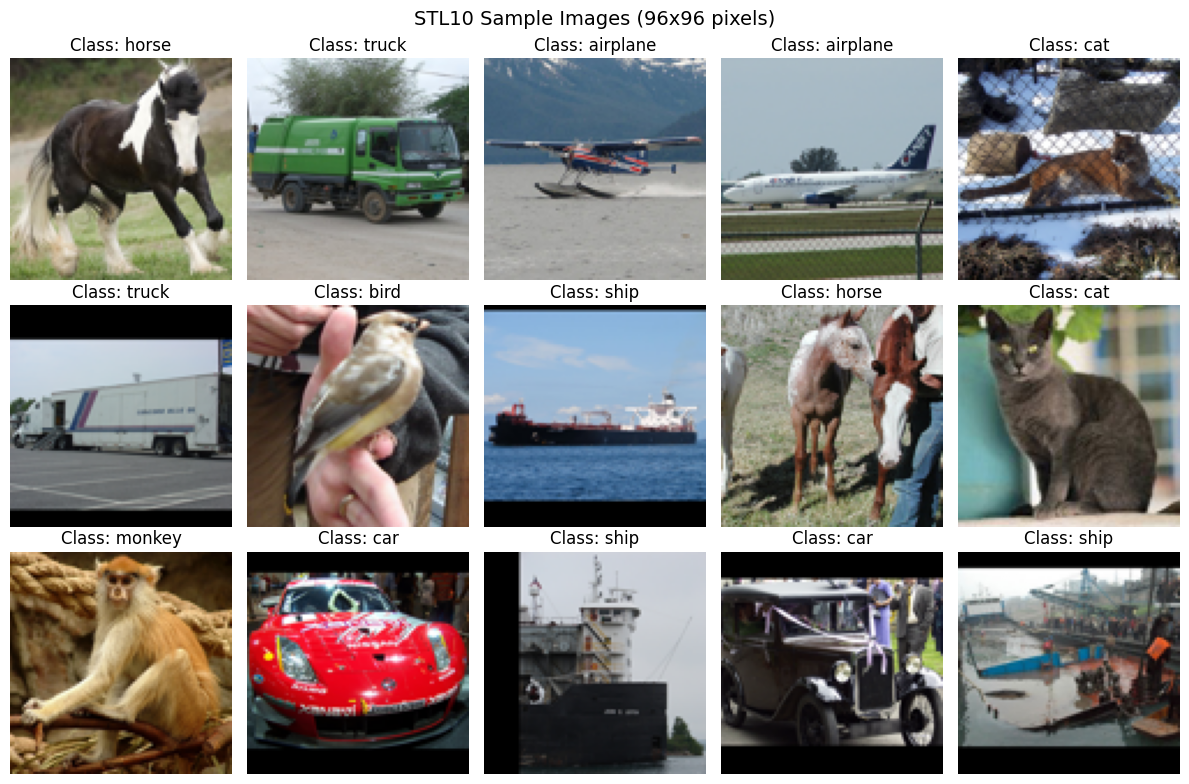

In [61]:
vis_dataset = torchvision.datasets.STL10(
    root='./data',
    split='train',
    download=False,  # Already downloaded
    transform=visual_transform
)

def denormalize(image, mean, std):
    """Denormalize image for visualization"""
    image = image.clone()
    for t, m, s in zip(image, mean, std):
        t.mul_(s).add_(m)
    return image

# Get class names for STL10
class_names = [
    'airplane', 'bird', 'car', 'cat', 'deer', 
    'dog', 'horse', 'monkey', 'ship', 'truck'
]

# Display sample images
fig, axes = plt.subplots(3, 5, figsize=(12, 8))
axes = axes.ravel()

# Show 15 random samples from training set
for idx in range(15):
    # Get random image
    random_idx = np.random.randint(0, len(vis_dataset))
    image, label = vis_dataset[random_idx]
    
    # Denormalize if needed (but visual_transform doesn't normalize)
    if image.shape[0] == 3:
        # Image is already in [0,1] range
        img_display = image.permute(1, 2, 0).numpy()
    else:
        img_display = image
    
    axes[idx].imshow(img_display)
    axes[idx].set_title(f'Class: {class_names[label]}')
    axes[idx].axis('off')

plt.suptitle('STL10 Sample Images (96x96 pixels)', fontsize=14)
plt.tight_layout()
plt.show()

In [62]:
train_images = torchvision.datasets.OxfordIIITPet(
    root='./data',
    split='trainval',
    target_types='category',
    download=True,
    transform=transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225])
    ])
)

train_masks = torchvision.datasets.OxfordIIITPet(
    root='./data',
    split='trainval',
    target_types='segmentation',
    download=True,
    transform=transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.PILToTensor()
    ])
)

test_images = torchvision.datasets.OxfordIIITPet(
    root='./data',
    split='test',
    target_types='category',
    download=True,
    transform=transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225])
    ])
)

test_masks = torchvision.datasets.OxfordIIITPet(
    root='./data',
    split='test',
    target_types='segmentation',
    download=True,
    transform=transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.PILToTensor()
    ])
)

In [63]:
class SegmentationDataset(Dataset):
    """Объединяет изображения и маски в один датасет"""
    def __init__(self, images_dataset, masks_dataset):
        self.images = images_dataset
        self.masks = masks_dataset
        assert len(self.images) == len(self.masks), f"Images: {len(self.images)}, Masks: {len(self.masks)}"
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        image = self.images[idx][0]  # (C, H, W)
        mask = self.masks[idx][0]    # (1, H, W) для сегментации
        return image, mask

# Создаем датасеты
full_train_dataset = SegmentationDataset(train_images, train_masks)
test_dataset = SegmentationDataset(test_images, test_masks)

# Разделяем trainval на train и val (80/20)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(
    full_train_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

print(f"\nРазделение данных:")
print(f"  Train: {len(train_dataset)} изображений")
print(f"  Validation: {len(val_dataset)} изображений")
print(f"  Test: {len(test_dataset)} изображений")


Разделение данных:
  Train: 2944 изображений
  Validation: 736 изображений
  Test: 3669 изображений


In [64]:
def check_data_sample(dataset, idx=0):
    """Проверяем один сэмпл"""
    image, mask = dataset[idx]
    print(f"\nПроверка данных:")
    print(f"  Image shape: {image.shape}")
    print(f"  Mask shape: {mask.shape}")
    print(f"  Image range: [{image.min():.3f}, {image.max():.3f}]")
    print(f"  Mask unique values: {torch.unique(mask)}")
    return image, mask

print("\nПроверка первого сэмпла:")
image, mask = check_data_sample(train_dataset)


Проверка первого сэмпла:

Проверка данных:
  Image shape: torch.Size([3, 256, 256])
  Mask shape: torch.Size([3, 256, 256])
  Image range: [-2.032, 2.640]
  Mask unique values: tensor([  2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,  14,  15,
         16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,  27,  28,  29,
         30,  31,  32,  33,  34,  35,  36,  37,  38,  39,  40,  41,  42,  43,
         44,  45,  46,  47,  48,  49,  50,  51,  52,  53,  54,  55,  56,  57,
         58,  59,  60,  61,  62,  63,  64,  65,  66,  67,  68,  69,  70,  71,
         72,  73,  74,  75,  76,  77,  78,  79,  80,  81,  82,  83,  84,  85,
         86,  87,  88,  89,  90,  91,  92,  93,  94,  95,  96,  97,  98,  99,
        100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113,
        114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127,
        128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141,
        142, 143, 144, 145, 146, 147, 148,

TypeError: Invalid shape (3, 256, 256) for image data

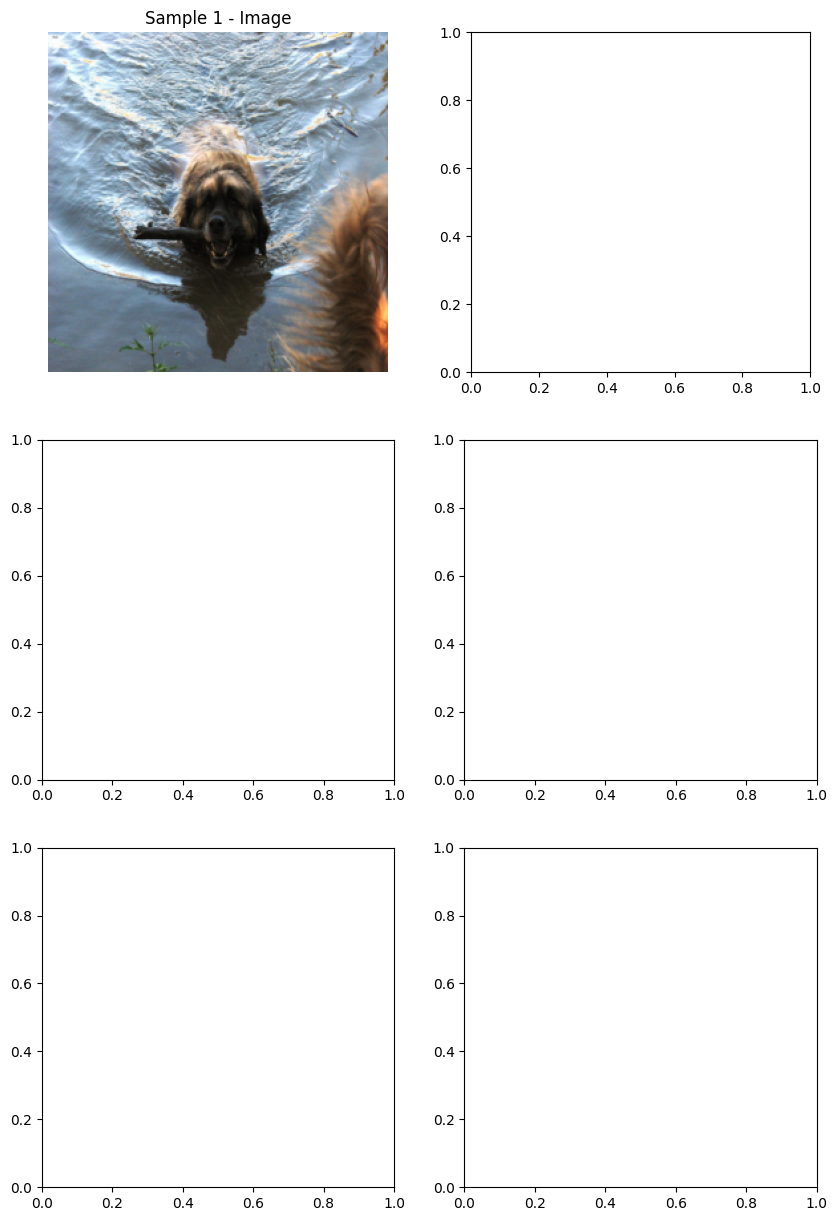

In [ ]:
def denormalize(tensor, mean, std):
    """
    Denormalize a tensor image.
    
    Args:
        tensor: Normalized tensor image (C, H, W)
        mean: Mean values used for normalization
        std: Standard deviation values used for normalization
    """
    # Clone tensor to avoid modifying original
    tensor = tensor.clone()
    
    # Denormalize
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    
    # Convert to numpy and clamp values
    tensor = tensor.numpy().transpose(1, 2, 0)
    tensor = np.clip(tensor, 0, 1)
    
    return tensor


def visualize_pet_segmentation(dataset, num_samples=3, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    fig, axes = plt.subplots(num_samples, 2, figsize=(10, 5*num_samples))
    
    for i in range(num_samples):
        # Get sample
        image, mask = dataset[i]
        
        # Denormalize image
        image_denorm = denormalize(image, mean, std)
        
        # Display image
        axes[i, 0].imshow(image_denorm)
        axes[i, 0].set_title(f'Sample {i+1} - Image')
        axes[i, 0].axis('off')
        
        # Display mask
        axes[i, 1].imshow(mask.squeeze(), cmap='gray')
        axes[i, 1].set_title(f'Sample {i+1} - Mask')
        axes[i, 1].axis('off')
    
    plt.tight_layout()
    plt.show()

# Use the function
visualize_pet_segmentation(train_dataset, num_samples=3)